# Subglacial hydrology of a mountain glacier

The previous tutorials modelled drainage beneath a large outlet glacier on a flat bed.
Mountain glaciers present a different challenge: they occupy narrow valleys with significant bed topography, and the bed slope can be steep enough that water flows *uphill* relative to the ice surface — a condition known as an **overdeepening**.

Overdeepenings are common in alpine settings (e.g., Bench Glacier, Alaska; Gorner Glacier, Switzerland) and have important consequences:

* Water can pond in overdeepenings, raising pressure and promoting sliding.
* The hydraulic potential gradient can reverse, trapping water and preventing efficient channel formation.
* Supercooling of water flowing out of overdeepenings can freeze shut channels from within.

In this tutorial we will:

1. Build a valley-glacier geometry with an unstructured mesh using gmsh.
2. Vary the bed-slope parameter $\gamma$ to create progressively deeper overdeepenings.
3. Run each configuration to steady state under high uniform recharge.
4. Compare how overdeepenings affect the effective pressure distribution and channel network.

## Valley geometry

Our glacier is modelled after Bench Glacier, Alaska — a 6 km long valley glacier that has been extensively studied for its subglacial hydrology (Fudge et al., 2009).

The ice surface is given by a power-law profile:

$$S(x) = 100\left(\frac{x}{6000} + (x + 200)^{1/4} - 200^{1/4}\right) + 1$$

The bed has a parabolic cross-valley shape with an along-flow slope controlled by the parameter $\gamma$:

$$B(x, y) = f(x, \gamma) + g(y)\, h(x, \gamma)$$

where $f$ is the centreline bed profile, $g(y) = \frac{1}{2} \times 10^{-6}\, |y|^3$ carves the valley walls, and $h$ scales the cross-valley shape to match the ice outline.

The key parameter is $\gamma$:
- $\gamma = +0.05$: reference geometry (Bench Glacier), gentle down-slope
- $\gamma = 0$: flat centreline bed
- $\gamma < 0$: **overdeepenings** — the bed rises towards the terminus, trapping water

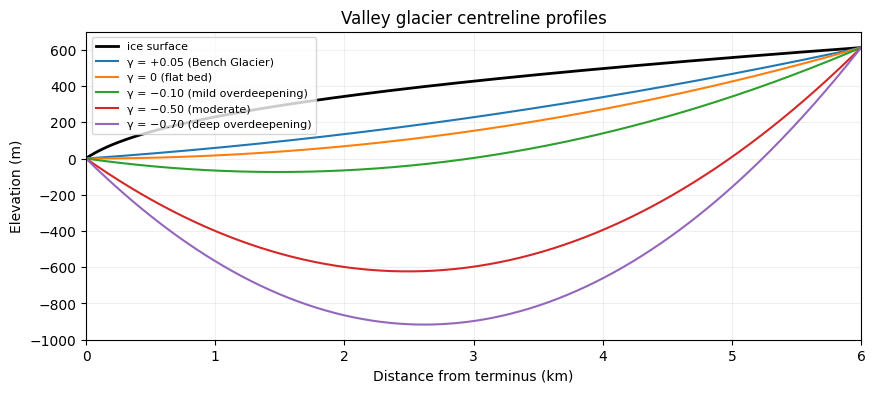

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Centreline profiles for different gamma values
Lx = 6000.0
x = np.linspace(0, Lx, 500)

# Surface
S = 100 * (x / Lx + (x + 200)**0.25 - 200**0.25) + 1
S_max = S[-1]

gammas = {"γ = +0.05 (Bench Glacier)": 0.05,
          "γ = 0 (flat bed)": 0.0,
          "γ = −0.10 (mild overdeepening)": -0.10,
          "γ = −0.50 (moderate)": -0.50,
          "γ = −0.70 (deep overdeepening)": -0.70}

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x / 1e3, S, "k-", lw=2, label="ice surface")

for label, gamma in gammas.items():
    f = gamma * x + (S_max - gamma * Lx) / Lx**2 * x**2
    ax.plot(x / 1e3, f, lw=1.5, label=label)

ax.set_xlabel("Distance from terminus (km)")
ax.set_ylabel("Elevation (m)")
ax.set_title("Valley glacier centreline profiles")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(0, 6)
ax.set_ylim(-1000, 700)
ax.grid(True, alpha=0.2);

## Building an unstructured mesh with gmsh

Unlike the rectangular meshes in Tutorials 01–02, a valley glacier needs an unstructured triangular mesh that conforms to the glacier outline.
The outline width varies with $x$ based on where the ice thickness goes to zero.
We use gmsh to generate the mesh and read it into Firedrake.

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


Valley mesh: 760 vertices, 1386 cells


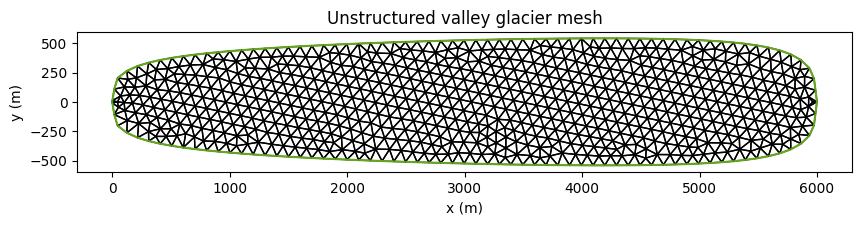

In [2]:
import firedrake as fd
import gmsh
import tempfile

from hydropack.models.subglacialhydrology import SubglacialHydrologyModel
from hydropack.constants import ice_density, water_density, gravity

Lx = 6000.0
GAMMA_BENCH = 0.05  # reference gamma for outline shape
EPS = 1e-16


def glacier_outline(gamma_ref=GAMMA_BENCH, n_pts=200):
    """Half-width y_o(x) where ice thickness = 0 on the bed."""
    x = np.linspace(0, Lx, n_pts)
    S = 100 * (x / Lx + (x + 200)**0.25 - 200**0.25) + 1
    S_max = S[-1]
    f_ref = gamma_ref * x + (S_max - gamma_ref * Lx) / Lx**2 * x**2
    # h(x) shape function at y=0 for reference gamma
    h_shape = (-4.5 * x / Lx + 5.0)
    # Half-width from g(y_o) * h = S - f  =>  0.5e-6 * y_o^3 * h = S - f
    diff = np.maximum(S - f_ref, EPS)
    y_o = (diff / (0.5e-6 * np.maximum(h_shape, EPS)))**(1.0 / 3.0)
    # Clamp and smooth
    y_o = np.minimum(y_o, 600.0)
    y_o[0] = 10.0  # narrow at terminus
    return x, y_o


def build_valley_mesh(lc=100.0):
    """Generate an unstructured gmsh mesh for the valley glacier."""
    x_out, y_out = glacier_outline()

    gmsh.initialize()
    gmsh.option.setNumber("General.Verbosity", 0)
    gmsh.model.add("valley")
    geo = gmsh.model.geo

    # Upper boundary (y > 0 side)
    pts_upper = [geo.addPoint(x_out[i], y_out[i], 0, lc) for i in range(len(x_out))]
    # Lower boundary (y < 0 side, reversed)
    pts_lower = [geo.addPoint(x_out[i], -y_out[i], 0, lc) for i in range(len(x_out))]

    # Connect with splines
    sp_upper = geo.addSpline(pts_upper)
    sp_head = geo.addLine(pts_upper[-1], pts_lower[-1])
    sp_lower = geo.addSpline(list(reversed(pts_lower)))
    sp_term = geo.addLine(pts_lower[0], pts_upper[0])

    loop = geo.addCurveLoop([sp_upper, sp_head, sp_lower, sp_term])
    geo.addPlaneSurface([loop])

    # Physical groups for BCs
    geo.synchronize()
    gmsh.model.addPhysicalGroup(1, [sp_term], tag=1, name="terminus")
    gmsh.model.addPhysicalGroup(1, [sp_upper, sp_head, sp_lower], tag=2, name="walls")
    gmsh.model.addPhysicalGroup(2, [1], tag=1, name="glacier")

    geo.synchronize()
    gmsh.model.mesh.generate(2)

    # Write to temp file and load into Firedrake
    with tempfile.NamedTemporaryFile(suffix=".msh", delete=False) as tmp:
        gmsh.write(tmp.name)
        mesh = fd.Mesh(tmp.name)

    gmsh.finalize()
    return mesh


mesh = build_valley_mesh(lc=100.0)
print(f"Valley mesh: {mesh.num_vertices()} vertices, {mesh.num_cells()} cells")

fig, ax = plt.subplots(figsize=(10, 3))
fd.triplot(mesh, axes=ax)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Unstructured valley glacier mesh")
ax.set_aspect("equal");

## Setting up the hydrology model on the valley mesh

The model setup is the same as in Tutorial 01, but now the bed elevation $B(x,y)$ has real topography and the mesh is unstructured.
We apply a uniform recharge of $1.16 \times 10^{-6}$ m/s (≈ 100 mm/day) — representative of peak summer melt on an alpine glacier.

In [3]:
M_RECHARGE = 2.0 * 5.79e-7   # ≈ 1.16e-6 m/s (100 mm/day)


def fd_surface(mesh):
    """Ice surface elevation S(x) on the valley mesh."""
    Q = fd.FunctionSpace(mesh, "CG", 1)
    x, y = fd.SpatialCoordinate(mesh)
    return fd.interpolate(
        100.0 * (x / Lx + (x + 200)**0.25 - 200**0.25) + 1.0, Q
    )


def fd_bed(mesh, gamma=GAMMA_BENCH):
    """Bed elevation B(x,y) with valley shape and overdeepening parameter gamma."""
    Q = fd.FunctionSpace(mesh, "CG", 1)
    x, y = fd.SpatialCoordinate(mesh)

    zs = fd_surface(mesh)
    S_max = float(zs.dat.data_ro.max())

    # Centreline bed profile
    f = gamma * x + (S_max - gamma * Lx) / Lx**2 * x**2

    # Reference profile (for scaling the cross-valley shape)
    f_bench = GAMMA_BENCH * x + (S_max - GAMMA_BENCH * Lx) / Lx**2 * x**2
    s_ref = fd.max_value(zs - f_bench, fd.Constant(1.0))

    # Cross-valley shape
    h_shape = (-4.5 * x / Lx + 5.0) * ((zs - f) / s_ref)
    g_cross = 0.5e-6 * fd.sqrt(y**2)**3

    return fd.interpolate(f + g_cross * h_shape, Q)


def make_valley_model(mesh, gamma=GAMMA_BENCH):
    """Create a SubglacialHydrologyModel for the valley geometry."""
    Q = fd.FunctionSpace(mesh, "CG", 1)
    CR = fd.FunctionSpace(mesh, "CR", 1)

    zs = fd_surface(mesh)
    zb = fd_bed(mesh, gamma)
    H = fd.interpolate(fd.max_value(zs - zb, fd.Constant(1.0)), Q)

    u_b = fd.Function(Q).interpolate(fd.Constant(1e-6))
    p_i = fd.Function(Q).interpolate(fd.Constant(ice_density * gravity) * H)
    phi_m = fd.Function(Q).interpolate(fd.Constant(water_density * gravity) * zb)
    phi_0 = fd.Function(Q).interpolate(p_i + phi_m)

    h_init = fd.interpolate(fd.Constant(0.01), Q)
    S_init = fd.interpolate(fd.Constant(1e-3), CR)
    phi_init = fd.Function(Q).interpolate(phi_0)

    m = fd.Function(Q).interpolate(fd.Constant(M_RECHARGE))

    bc = fd.DirichletBC(Q, phi_m, [1])  # terminus

    return SubglacialHydrologyModel(
        mesh,
        thickness=H, bed=zb, sliding_speed=u_b, melt_rate=m,
        phi_init=phi_init, h_init=h_init, S_init=S_init,
        phi_m=phi_m, p_i=p_i, phi_0=phi_0,
        dirichlet_bcs=[bc],
    )

## Running the overdeepening experiments

We run the reference geometry ($\gamma = +0.05$) and two overdeepenings ($\gamma = -0.10$ and $\gamma = -0.50$).
The reference case has a gently down-sloping bed and drains easily; the overdeepenings trap water and alter the pressure distribution.

In [4]:
def advance_to_steady(model, dt, melt_rate=None, *, rel_tol=5e-4,
                      max_steps=5000, check_every=6, ramp_steps=50):
    """Run the model to steady state with an optional gradual recharge ramp."""
    if melt_rate is not None:
        dt_ramp = min(dt, 3600.0)  # 1-hour steps during ramp
        for frac in [0.01, 0.02, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]:
            model.m.interpolate(fd.Constant(frac * melt_rate))
            for _ in range(ramp_steps):
                model.step(dt)
            model.update_phi()
        model.m.interpolate(fd.Constant(melt_rate))

    phi_prev = fd.Function(model.U).interpolate(model.phi)
    N_prev = fd.Function(model.U).interpolate(model.N)
    h_prev = fd.Function(model.U).interpolate(model.h)
    S_prev = fd.Function(model.CR).interpolate(model.S)

    for k in range(1, max_steps + 1):
        model.step(dt)
        if k % check_every == 0:
            model.update_phi()
            rphi = float(fd.norm(model.phi - phi_prev) / (fd.norm(model.phi) + 1e-30))
            rN = float(fd.norm(model.N - N_prev) / (fd.norm(model.N) + 1e-30))
            rh = float(fd.norm(model.h - h_prev) / (fd.norm(model.h) + 1e-30))
            rS = float(fd.norm(model.S - S_prev) / (fd.norm(model.S) + 1e-30))
            phi_prev.assign(model.phi); N_prev.assign(model.N)
            h_prev.assign(model.h); S_prev.assign(model.S)
            sim_days = k * dt / 86400
            if k % (check_every * 50) == 0:
                print(f"  day {sim_days:.0f}: rphi={rphi:.2e} rN={rN:.2e} rh={rh:.2e} rS={rS:.2e}")
            if rphi < rel_tol and rN < rel_tol and rh < rel_tol and rS < rel_tol:
                print(f"  Converged at day {sim_days:.0f} (step {k})")
                return k
    print(f"  WARNING: did not converge in {max_steps} steps")
    return max_steps


dt = 14400  # 4-hour timestep

gamma_cases = {
    "reference (γ = +0.05)": 0.05,
    "overdeepening (γ = −0.50)": -0.50,
}

valley_results = {}

for label, gamma in gamma_cases.items():
    print(f"\n=== {label} ===")
    model = make_valley_model(mesh, gamma=gamma)

    # Initialise phi at overburden
    model.phi.dat.data[:] = model.phi_0.dat.data_ro
    model.update_phi()

    # Ramp recharge and run to steady state
    advance_to_steady(model, dt, melt_rate=M_RECHARGE)

    model.update_phi()
    valley_results[label] = model


=== reference (γ = +0.05) ===


/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.
/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpola

  day 50: rphi=4.54e-04 rN=1.69e-04 rh=1.46e-04 rS=7.18e-03
  day 100: rphi=1.77e-04 rN=6.59e-05 rh=4.03e-05 rS=2.08e-03
  day 150: rphi=1.04e-04 rN=3.87e-05 rh=2.31e-05 rS=1.72e-03
  day 200: rphi=9.82e-05 rN=3.66e-05 rh=1.91e-05 rS=1.53e-03
  day 250: rphi=5.90e-05 rN=2.20e-05 rh=1.16e-05 rS=1.37e-03
  day 300: rphi=3.32e-05 rN=1.24e-05 rh=6.35e-06 rS=1.24e-03
  day 350: rphi=1.37e-05 rN=5.10e-06 rh=2.63e-06 rS=1.13e-03
  day 400: rphi=1.99e-05 rN=7.43e-06 rh=3.88e-06 rS=8.35e-04
  day 450: rphi=1.38e-05 rN=5.16e-06 rh=3.08e-06 rS=7.99e-04
  day 500: rphi=6.48e-06 rN=2.42e-06 rh=1.78e-06 rS=7.66e-04
  day 550: rphi=5.79e-06 rN=2.16e-06 rh=7.06e-07 rS=7.36e-04
  day 600: rphi=4.31e-06 rN=1.61e-06 rh=2.54e-07 rS=7.09e-04
  day 650: rphi=5.43e-06 rN=2.03e-06 rh=2.10e-07 rS=6.84e-04
  day 700: rphi=4.78e-06 rN=1.79e-06 rh=2.36e-07 rS=6.61e-04
  day 750: rphi=4.69e-06 rN=1.75e-06 rh=2.73e-07 rS=6.41e-04
  day 800: rphi=8.28e-06 rN=3.09e-06 rh=4.05e-07 rS=6.23e-04

=== overdeepening (γ = −

/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.


  day 50: rphi=2.13e-03 rN=4.43e-04 rh=1.68e-04 rS=7.97e-03
  day 100: rphi=3.26e-03 rN=6.10e-04 rh=2.32e-04 rS=5.24e-03
  day 150: rphi=1.58e-03 rN=2.82e-04 rh=1.70e-04 rS=3.75e-03
  day 200: rphi=1.21e-03 rN=1.99e-04 rh=1.49e-04 rS=2.47e-03
  day 250: rphi=3.06e-04 rN=4.93e-05 rh=2.47e-05 rS=1.12e-03
  day 300: rphi=4.42e-04 rN=7.12e-05 rh=1.64e-05 rS=9.87e-04
  day 350: rphi=8.14e-05 rN=1.31e-05 rh=3.00e-06 rS=8.86e-04
  day 400: rphi=4.94e-05 rN=7.96e-06 rh=2.61e-06 rS=8.09e-04
  day 450: rphi=7.21e-05 rN=1.16e-05 rh=2.50e-06 rS=7.47e-04
  day 500: rphi=4.83e-05 rN=7.79e-06 rh=2.63e-06 rS=6.97e-04
  day 550: rphi=7.76e-05 rN=1.25e-05 rh=3.46e-06 rS=6.57e-04
  day 600: rphi=6.82e-05 rN=1.10e-05 rh=5.05e-06 rS=6.29e-04
  day 650: rphi=1.22e-04 rN=1.98e-05 rh=8.55e-06 rS=6.17e-04
  day 700: rphi=9.98e-05 rN=1.62e-05 rh=5.85e-05 rS=6.56e-04
  day 750: rphi=4.27e-05 rN=6.93e-06 rh=4.51e-06 rS=5.48e-04
  day 800: rphi=3.73e-04 rN=6.06e-05 rh=1.27e-04 rS=5.71e-04


## Comparing effective pressure across geometries

For each geometry, we compute the width-averaged effective pressure along the centreline.
With overdeepenings, we expect:

* Lower $N$ (higher water pressure) in the overdeepened region where water pools.
* A pressure "bump" at the lip of the overdeepening where water must be forced uphill.
* Potentially weaker channelisation, since the adverse hydraulic gradient suppresses the dissipation that drives channel formation.

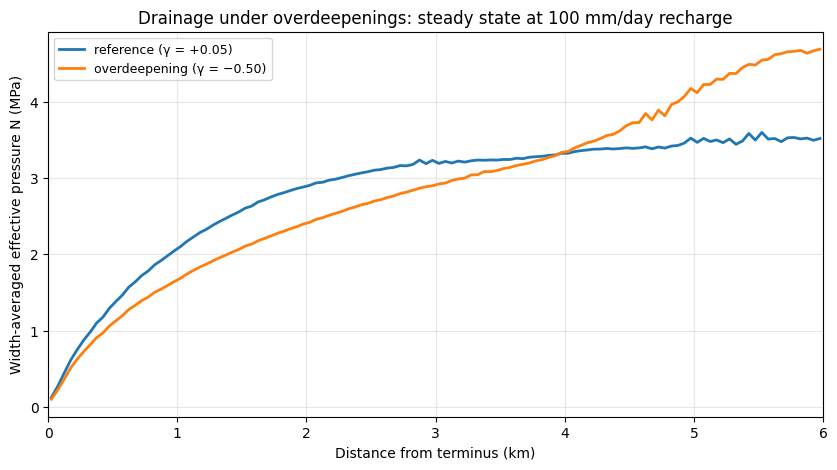

In [5]:
def width_averaged_Nx_dg0(model, Lx=6000.0, nbins=120, band_half=100.0):
    """Area-weighted N(x) in a narrow centre strip (for valley meshes)."""
    N0 = fd.Function(fd.FunctionSpace(model.mesh, "DG", 0)).project(model.N)
    N0v = N0.dat.data_ro

    VdgV = fd.VectorFunctionSpace(model.mesh, "DG", 0)
    coords = fd.Function(VdgV).interpolate(fd.SpatialCoordinate(model.mesh))
    xc, yc = coords.dat.data_ro[:, 0], coords.dat.data_ro[:, 1]

    A = fd.Function(fd.FunctionSpace(model.mesh, "DG", 0)).interpolate(
        fd.CellVolume(model.mesh)).dat.data_ro

    mask = np.abs(yc) <= band_half
    bins = np.linspace(0, Lx, nbins + 1)
    ix = np.clip(np.searchsorted(bins, xc[mask], side="right") - 1, 0, nbins - 1)
    Nsum = np.zeros(nbins)
    Asum = np.zeros(nbins)
    np.add.at(Nsum, ix, N0v[mask] * A[mask])
    np.add.at(Asum, ix, A[mask])
    bad = Asum == 0
    Nsum[bad] = np.nan
    Asum[bad] = np.nan
    xmid = 0.5 * (bins[:-1] + bins[1:])
    return xmid, Nsum / Asum


fig, ax = plt.subplots(figsize=(10, 5))

for label, model in valley_results.items():
    xc, Nx = width_averaged_Nx_dg0(model)
    keep = ~np.isnan(Nx)
    ax.plot(xc[keep] / 1e3, Nx[keep] / 1e6, lw=2, label=label)

ax.set_xlabel("Distance from terminus (km)")
ax.set_ylabel("Width-averaged effective pressure N (MPa)")
ax.set_title("Drainage under overdeepenings: steady state at 100 mm/day recharge")
ax.legend(fontsize=9)
ax.set_xlim(0, 6)
ax.grid(True, alpha=0.3);

## Spatial maps and channel networks

To see the full 2D structure, we plot effective pressure, sheet thickness, the channel network, and the flotation fraction.
`hydropack.plot.tripcolor_cr` draws CR1 edge fields as colored line segments — the same calling convention as `firedrake.tripcolor` for CG1 fields.

/home/andrew/venv-firedrake/lib/python3.10/site-packages/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.


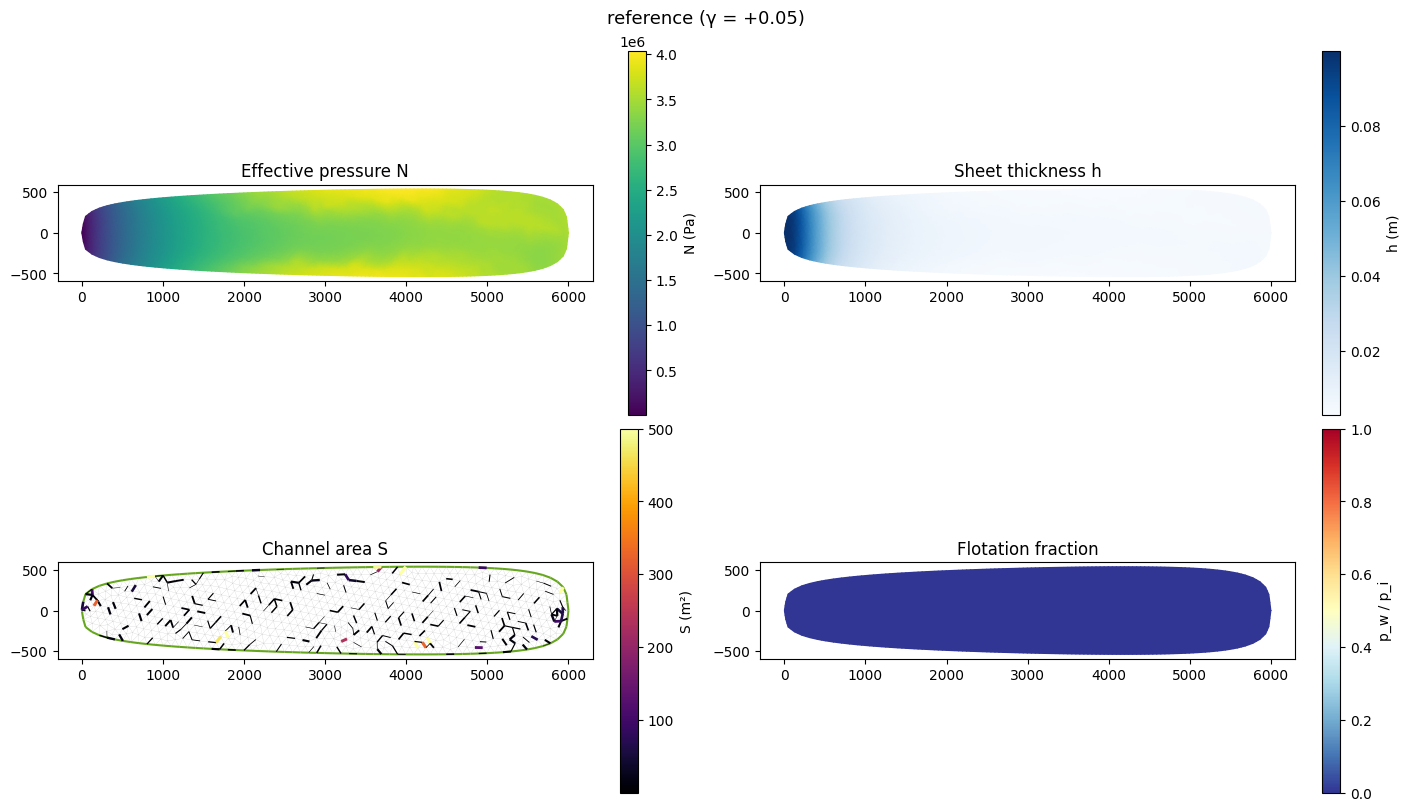

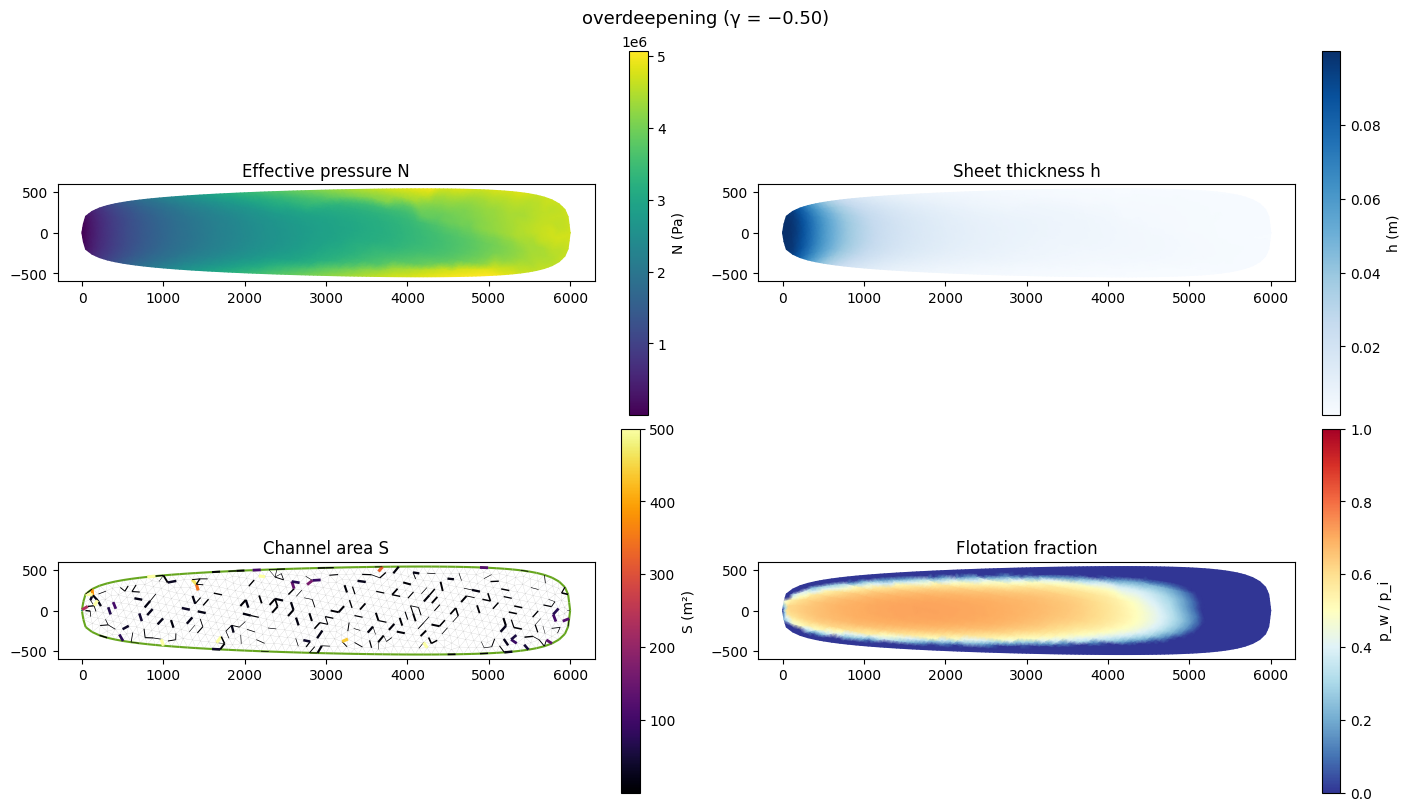

In [6]:
import hydropack.plot as hplot

for label, model in valley_results.items():
    model.compute_flux_fields()
    model.update_pfo()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

    ax = axes[0, 0]
    c = fd.tripcolor(model.N, axes=ax, cmap="viridis")
    fig.colorbar(c, ax=ax, label="N (Pa)")
    ax.set_title("Effective pressure N")
    ax.set_aspect("equal")

    ax = axes[0, 1]
    c = fd.tripcolor(model.h, axes=ax, cmap="Blues")
    fig.colorbar(c, ax=ax, label="h (m)")
    ax.set_title("Sheet thickness h")
    ax.set_aspect("equal")

    ax = axes[1, 0]
    fd.triplot(model.mesh, axes=ax, interior_kw={"linewidth": 0.1, "alpha": 0.2})
    lc = hplot.tripcolor_cr(model.S, axes=ax, cmap="inferno", threshold=0.01)
    fig.colorbar(lc, ax=ax, label="S (m²)")
    ax.set_title("Channel area S")
    ax.set_aspect("equal")

    ax = axes[1, 1]
    c = fd.tripcolor(model.pfo, axes=ax, cmap="RdYlBu_r", vmin=0, vmax=1)
    fig.colorbar(c, ax=ax, label="p_w / p_i")
    ax.set_title("Flotation fraction")
    ax.set_aspect("equal")

    fig.suptitle(label, fontsize=13);

## Supercooling diagnostic

When water flows up an adverse bed slope (out of an overdeepening), the pressure-melting point rises.
If the water can't absorb heat fast enough, it becomes **supercooled** and refreezes — potentially shutting down channels from within.

In our model, this is captured by the Clausius–Clapeyron term $\Pi$.
The ratio $\Pi / \Xi$ tells us how much of the dissipation energy is consumed by warming the water:

For $\Pi / \Xi < 1$, we expect net melting and channels can grow.

For $\Pi / \Xi > 1$: we expect **supercooling** and conduits should refreeze.

We can compute this ratio from the model state to see exactly where supercooling occurs.

/tmp/ipykernel_2168477/2473873601.py:28: RuntimeWarning: invalid value encountered in divide
  ratio_edge = np.where(Xi_edge > 1e-30, Pi_edge / Xi_edge, 0.0)


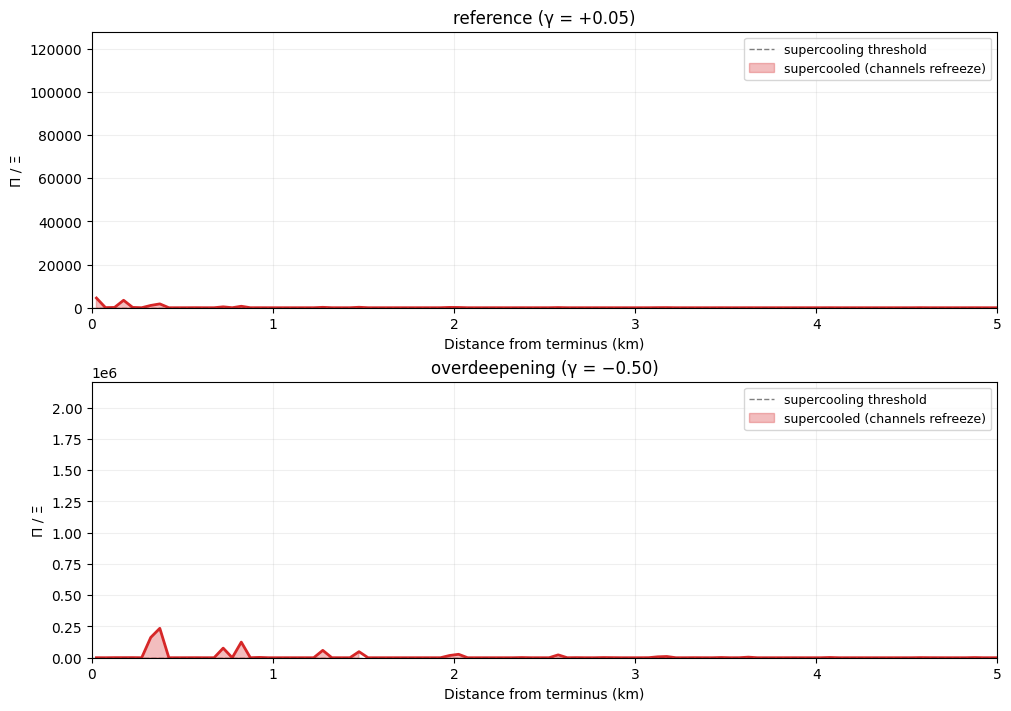

In [9]:
from hydropack.constants import (
    ice_density, water_density, gravity,
    clapeyron_slope, heat_capacity_water,
    sheet_flux_alpha, sheet_flux_beta,
)

def supercooling_ratio(model, Lx=6000.0, nbins=120, band_half=100.0):
    """Compute the centreline Pi/Xi ratio (supercooling diagnostic).
    
    Returns (x_centres, ratio) where ratio > 1 means supercooling.
    """
    # Get phi and phi_m gradients on CR edges
    phi_s = model.dphi_ds_cr.dat.data_ro.copy()       # d(phi)/ds
    pw_s = model.utilities.ds_array(model.phi - model.phi_m)  # d(phi - phi_m)/ds
    phim_s = phi_s - pw_s                                     # d(phi_m)/ds
    
    # Dissipation: Xi = |Q * dphi/ds| ∝ |dphi/ds|^beta
    k_c = model.k_c
    S_vals = np.abs(model.S.dat.data_ro)
    abs_phi = (phi_s**2 + 1e-20)**(sheet_flux_beta / 2.0 - 1.0)
    Xi_edge = np.abs(k_c * S_vals**sheet_flux_alpha * abs_phi * phi_s * phi_s)
    
    # Clapeyron: Pi = c_t * c_w * rho_w * |Q| * |d(phi-phi_m)/ds|
    C = clapeyron_slope * heat_capacity_water * water_density
    Pi_edge = C * np.abs(k_c * S_vals**sheet_flux_alpha * abs_phi * phi_s) * np.abs(pw_s)
    
    # Ratio (avoid division by zero)
    ratio_edge = np.where(Xi_edge > 1e-30, Pi_edge / Xi_edge, 0.0)
    
    # Average along centreline using edge midpoints
    dm = model.mesh.topology_dm
    vStart, _ = dm.getDepthStratum(0)
    eStart, eEnd = dm.getDepthStratum(1)
    
    sec = dm.getCoordinateSection()
    coords_local = dm.getCoordinatesLocal()
    arr = coords_local.array
    
    # Edge midpoint x-coordinates
    x_mid = np.zeros(eEnd - eStart)
    y_mid = np.zeros(eEnd - eStart)
    for i, e in enumerate(range(eStart, eEnd)):
        cone = dm.getCone(e)
        off0 = sec.getOffset(int(cone[0]))
        off1 = sec.getOffset(int(cone[1]))
        x_mid[i] = 0.5 * (arr[off0] + arr[off1])
        y_mid[i] = 0.5 * (arr[off0 + 1] + arr[off1 + 1])
    
    # Bin along centreline
    mask = np.abs(y_mid) <= band_half
    bins = np.linspace(0, Lx, nbins + 1)
    xc = 0.5 * (bins[:-1] + bins[1:])
    ix = np.clip(np.searchsorted(bins, x_mid[mask], side="right") - 1, 0, nbins - 1)
    
    ratio_sum = np.zeros(nbins)
    count = np.zeros(nbins)
    np.add.at(ratio_sum, ix, ratio_edge[mask])
    np.add.at(count, ix, 1)
    
    ratio_avg = np.where(count > 0, ratio_sum / count, 0.0)
    return xc, ratio_avg


fig, axes = plt.subplots(len(valley_results), 1,
                          figsize=(10, 3.5 * len(valley_results)),
                          constrained_layout=True, squeeze=False)

for ax, (label, model) in zip(axes.flat, valley_results.items()):
    model.update_phi()
    model.update_dphi_ds_cr()
    
    xc, ratio = supercooling_ratio(model)
    
    ax.plot(xc / 1e3, ratio, "C3-", lw=2)
    ax.axhline(1.0, color="k", ls="--", lw=1, alpha=0.5, label="supercooling threshold")
    ax.fill_between(xc / 1e3, ratio, 1.0,
                     where=ratio > 1.0, alpha=0.3, color="C3",
                     label="supercooled (channels refreeze)")
    ax.set_xlabel("Distance from terminus (km)")
    ax.set_ylabel("Π / Ξ")
    ax.set_title(f"{label}")
    ax.legend(fontsize=9)
    ax.set_xlim(0, 5)
    ax.set_ylim(0, max(3, ratio.max() * 1.2))
    ax.grid(True, alpha=0.2)


## Conclusion

Mountain glaciers with overdeepenings exhibit fundamentally different drainage behaviour from flat-bed geometries:

The **reference glacier** ($\gamma = +0.05$) develops a well-connected channel network that drains water efficiently from headwall to terminus, maintaining moderate effective pressure.

With **deep overdeepenings** ($\gamma = -0.50$), the hydraulic potential gradient reverses over a significant fraction of the bed.  Water is trapped, $N$ drops toward zero in the overdeepened zone, and the **supercooling diagnostic** ($\Pi / \Xi > 1$) shows that channels actively refreeze in the adverse-slope region.

The supercooling physics is captured entirely by the Clausius–Clapeyron term $\Pi$ that is already part of the hydrology equations — no additional model is needed.  The $\Pi / \Xi$ ratio provides a direct diagnostic: where it exceeds 1, the energy required to warm water flowing up the adverse slope exceeds the viscous dissipation, and ice precipitates on the channel walls.

This has real consequences for glacier dynamics: supercooling-driven channel closure maintains high basal water pressure in overdeepenings.

### Next steps

**Seasonal forcing on the valley geometry**: Apply a degree-day melt model to study how the drainage system evolves through the melt season — do channels form in spring and get shut down by supercooling in the overdeepening?

**Coupling to ice dynamics**: Use hydropack's effective pressure output as a boundary condition for icepack's sliding law, creating a coupled ice-dynamics hydrology simulation.